<a href="https://colab.research.google.com/github/hannahishimwe/AgenticRPGChunking/blob/main/notebooks/agentic_RGPLE_chunking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Agentic Chunker
###To create chunked up Document Objects from larger unchunked Document objects

In [ ]:
%%capture
!pip install langchain_google_genai
!pip install langchain
!pip install langchain-core
!pip install --upgrade langchain-community

#RPGLELoader Class
####Brought over from previous notebook

In [ ]:
import os
import re
from typing import List
from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document

"""
Custom loader for RPGLE files in LangChain. Restricted to only RPGLE files.

Param: Path: a whole repository, or a single file.

Return: List of Documents, separating procedures from the rest of the file.

Metadata includes:
  - Source (the filepath)
  - Format
"""
class RPGLELoader(BaseLoader):

    def __init__(self, path: str):
        self.path = path

        """
        Error checking in case user inputs a non-existent path.
        """
        if os.path.isdir(path):
            self.is_repository = True
        elif os.path.isfile(path):
            self.is_repository = False
        else:
            raise ValueError(f"Path '{path}' is neither a file nor a directory.")

    def load(self) -> List[Document]:
      """
      Main method used, selects correct method to create Document objects dependent on
      whether user is loading a repository or a single file.

      Params: None
      Returns: List of Documents
      """
      if self.is_repository:
        return self.load_repository()
      else:
        return self.load_document(self.path)


    def find_rpg_files(self, root_dir: str) -> List[str]:
      """
      Method to find all RPGLE files in a repository.

      Params: Filepath, str
      Returns: List of RPGLE files as strings
      """
      pattern = re.compile(r'rpgle', re.IGNORECASE)
      rpg_files = []
      for dirpath, _, files in os.walk(root_dir):
          for file in files:
              _, ext = os.path.splitext(file)
              if pattern.search(ext):
                  rpg_files.append(os.path.join(dirpath, file))
      return rpg_files

    def load_repository(self) -> List[Document]:
        """
        Method to apply load_document to all RPGLE files in a repository.

        Params: None
        Returns: List of Documents
        """
        rpg_files = self.find_rpg_files(self.path)
        all_docs = []
        for rpg_file in rpg_files:
            doc = self.load_document(rpg_file)
            all_docs.extend(doc)
        return all_docs

    def load_document(self, path: str) -> List[Document]:
      chosen_path = path
      with open(chosen_path, 'r', encoding='utf-8') as f:
          source = f.read()
          source = source.replace('\r\n', '\n').replace('\r', '\n') # normalise to prevent OS-related formatting issues when analysing

      doc = Document(
                page_content=source,
                metadata={
                    "source": chosen_path,
                }
            )

      return [doc]



#Agentic Chunker Class

In [ ]:
from typing import List, Tuple
from langchain.schema import Document, SystemMessage, HumanMessage

class AgenticRPGChunker:

  def __init__(self, llm, chunk_size=1000, chunk_overlap=20):
    if llm is None:
        raise ValueError("llm must not be None")
    self.llm = llm
    self.chunk_size = chunk_size
    self.chunk_overlap = chunk_overlap

  def split_text(self, text: str) -> List[tuple[str, str, str]]:

    system_message = SystemMessage(content="You are an AI assistant helping to split RPGLE files into meaningful chunks for the use of LLM RAG. You can identify the difference between free and fixed format")

    human_message = HumanMessage(content=f"""Split the following RPGLE source code into chunks.

                Each chunk is a contiguous block of source code representing one logical unit, such as:

                - Control specification (e.g., Ctl-Opt ...)
                - Prototype (Dcl-Pr ... End-Pr)
                - Procedure (Dcl-Proc ... End-Proc)
                - Data structure (Dcl-Ds ... End-Ds)
                - Declaration of a specification
                - Comment block (consecutive comment lines). Do NOT group comment lines and executable code together.
                - Include statement

                Rules:

                - Do not change any character, spacing, or line breaks.
                - Keep chunks exactly as they appear.
                - Consecutive comment lines belong in one chunk.
                - Keep original order.
                - For each chunk, output the chunk **preceded by a single line** containing:

                    --- [format] | [spec]

                Where:

                - [format] is either "free" or "fixed"
                - [spec] is the chunk type (e.g., control, prototype, procedure, data structure, filedecl, comment, include, declaration of scalar)

                Example:

                Input:

                Dcl-Pr Example ExtPgm;
                Value Char(10);
                End-Pr;

                Output:

                --- free | prototype
                Dcl-Pr Example ExtPgm;
                Value Char(10);
                End-Pr;

                Now process the following RPGLE source:

                {text}
                """)

    response = self.llm.invoke([system_message, human_message])

    chunks = self.parse_chunks(response.content)

    return chunks


  def parse_chunks(self, text: str) -> List[Tuple[str, str, str]]:
    chunks = []
    parts = re.split(r'\n---\s*', '\n' + text.strip())  # Add initial \n to capture first chunk correctly
    for part in parts:
        if not part.strip():
            continue
        header, *body_lines = part.splitlines()
        header = header.strip() # e.g. fixed | procedure
        m = re.match(r'(free|fixed)\s*\|\s*(\w+)', header, re.IGNORECASE)
        if not m:
            continue
        fmt = m.group(1).lower()
        spec = m.group(2).lower()

        chunk_text = '\n'.join(body_lines)
        if not chunk_text.strip():
            continue
        if len(chunk_text) > self.chunk_size:
          chunks.extend(self.chunk_long_text(fmt, spec, chunk_text))
        chunks.append((fmt, spec, chunk_text))
    return chunks

  def split_document(self, document: Document) -> List[Document]:
    chunks = self.split_text(document.page_content)
    for i, (fmt, spec, chunk_text) in enumerate(chunks):
          new_metadata = dict(document.metadata)
          new_metadata['chunk_number'] = i
          new_metadata['format'] = fmt
          new_metadata['spec'] = spec
          yield Document(page_content=chunk_text, metadata=new_metadata)

  def split_documents(self, documents: List[Document]) -> List[Document]:
      return [chunk for document in documents for chunk in self.split_document(document)]

  def chunk_long_text(self, fmt, spec, text) -> List[tuple[str,str,str]]:
      """
      This breaks up text that is longer than character limit, ensures overlap so does not cut off in middle of a line
      """
      chunks = []
      start = 0

      while start < len(text):
          end = start + self.chunk_size
          chunk_text = text[start:end]


          last_newline = chunk_text.rfind('\n')
          last_semicolon = chunk_text.rfind(';')
          cut_point = max(last_newline, last_semicolon)

          min_length_threshold = 0.3 #delimiter must be at least 1/3 way into the chunk
          if cut_point != -1 and cut_point > 0.3 * self.chunk_size:
              end = start + cut_point + 1


          chunk = ((fmt, spec, text[start:end]))
          chunks.append(chunk)


          next_start = end - self.chunk_overlap
          if next_start >= len(text):
              break

          window = text[next_start:end]
          overlap_cut = max(window.rfind(';'), window.rfind('\n'))
          if overlap_cut != -1:
              start = next_start + overlap_cut + 1
          else:
              start = end



      return chunks




#Agentic Pt 2

In [ ]:
from typing import List, Tuple
from langchain.schema import Document, SystemMessage, HumanMessage

class AgenticRPGChunker:

  def __init__(self, llm, chunk_size=1000, chunk_overlap=20):
    if llm is None:
        raise ValueError("llm must not be None")
    self.llm = llm
    self.chunk_size = chunk_size
    self.chunk_overlap = chunk_overlap

  def split_text(self, text: str) -> List[tuple[str, str, str]]:

    system_message = SystemMessage(content="""
        You are an AI assistant that splits RPGLE source code into logical chunks for code search and cross-file dependency mapping.

        Each chunk must represent a single unit, such as:
        - Control specification (e.g., Ctl-Opt ...)
        - Prototype block (Dcl-Pr ... End-Pr)
        - Procedure or program interface (Dcl-Proc ... End-Proc or Dcl-Pi ... End-Pi)
        - Data structure (Dcl-Ds ... End-Ds)
        - Scalar or constant declarations (Dcl-S, Dcl-C)
        - File declarations
        - Include statements (/COPY, /INCLUDE)
        - Consecutive comment lines

        Rules:
        - Preserve all content exactly as-is: spacing, indentation, line breaks.
        - Do not merge code and comments into one chunk.
        - Do not split blocks that belong together.
        - Keep chunks in the original order.
        - Identify if a prototype declares an external or internal procedure:
            - Internal: Procedure defined in the same file.
            - External: Procedure declared with ExtPgm or ExtProc and invoked, or resolved from bound directories.
            - Procedures with the same name in different files are considered different unless they are actual external calls to the same program.
        - If a chunk only calls external procedures but is itself defined within the file, mark as 'internal'.

        Each chunk must be preceded by a header line in this exact format:

        --- [format] | [type] | [proc_name] | [external/internal]

        Where:
        - format: "free" or "fixed"
        - type: one of control, prototype, procedure, data structure, scalar, filedecl, include, comment
        - proc_name: name of the procedure or prototype defined or declared in the chunk, usually after the dcl keyword.
        - external/internal: "external" if chunk references external procedure/program/file, otherwise "internal"

        Output only the header line and the chunk. No additional text or commentary.

        Example:

        Input:
        Ctl-Opt DftActGrp(*No);
        /copy qcpysrc,commonutils

        Dcl-Pr NewEmp ExtPgm;
        DepartmentNumber Char(3);
        End-Pr;

        Output:
        --- free | control | | internal
        Ctl-Opt DftActGrp(*No);
        --- free | include | | external
        /copy qcpysrc,commonutils

        --- free | prototype | NewEmp | external
        Dcl-Pr NewEmp ExtPgm;
        DepartmentNumber Char(3);
        End-Pr;

        """)

    human_message = HumanMessage(content=f"""
    [file_name: {text}]

    """)
    response = self.llm.invoke([system_message, human_message])

    chunks = self.parse_chunks(response.content)

    return chunks


  def parse_chunks(self, text: str) -> List[Tuple[str, str, str, str, str]]:
    """
    Parses chunked RPGLE text and returns a list of tuples:
    (chunk_id, format, type, proc_name, file_name, chunk_text)
    """
    chunks = []
    parts = re.split(r'\n---\s*', '\n' + text.strip())  # Ensure first chunk is captured
    for part in parts:
        if not part.strip():
            continue
        header, *body_lines = part.splitlines()
        header = header.strip()
        # Match the full 5-field header
        m = re.match(
            r'(free|fixed)\s*\|\s*(\w+)\s*\|\s*(.*?)\s*\|\s*(external|internal)',
            header,
            re.IGNORECASE
        )
        if not m:
            continue
        fmt = m.group(1).lower()
        spec = m.group(2).lower()
        proc_name = m.group(3).strip()
        is_external = m.group(4).strip()

        chunk_text = '\n'.join(body_lines).rstrip()
        if not chunk_text:
            continue

        if len(chunk_text) > self.chunk_size:
            chunks.extend(self.chunk_long_text(fmt, spec, proc_name, is_external, chunk_text))
        chunks.append((fmt, spec, proc_name, is_external, chunk_text))
    return chunks




  def split_document(self, document: Document) -> List[Document]:
    chunks = self.split_text(document.page_content)
    for i, ( fmt, spec, proc_name, is_external, chunk_text) in enumerate(chunks):
          new_metadata = dict(document.metadata)
          new_metadata['chunk_id'] = i
          new_metadata['format'] = fmt
          new_metadata['spec'] = spec
          new_metadata['proc_name'] = proc_name
          new_metadata['type'] = is_external
          yield Document(page_content=chunk_text, metadata=new_metadata)


  def split_documents(self, documents: List[Document]) -> List[Document]:
      return [chunk for document in documents for chunk in self.split_document(document)]

  def chunk_long_text(self, fmt, spec, proc_name, is_external, text) -> List[tuple[str,str,str]]:
      """
      This breaks up text that is longer than character limit, ensures overlap so does not cut off in middle of a line
      """
      chunks = []
      start = 0

      while start < len(text):
          end = start + self.chunk_size
          chunk_text = text[start:end]


          last_newline = chunk_text.rfind('\n')
          last_semicolon = chunk_text.rfind(';')
          cut_point = max(last_newline, last_semicolon)

          min_length_threshold = 0.3 #delimiter must be at least 1/3 way into the chunk
          if cut_point != -1 and cut_point > 0.3 * self.chunk_size:
              end = start + cut_point + 1


          chunk = ((fmt, spec, proc_name, is_external, text[start:end]))
          chunks.append(chunk)


          next_start = end - self.chunk_overlap
          if next_start >= len(text):
              break

          window = text[next_start:end]
          overlap_cut = max(window.rfind(';'), window.rfind('\n'))
          if overlap_cut != -1:
              start = next_start + overlap_cut + 1
          else:
              start = end



      return chunks




#Testing

In [ ]:
!git clone https://github.com/IBM/ibmi-company_system.git

Cloning into 'ibmi-company_system'...
remote: Enumerating objects: 668, done.
remote: Counting objects: 100% (256/256), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 668 (delta 187), reused 157 (delta 157), pack-reused 412 (from 2)
Receiving objects: 100% (668/668), 103.19 KiB | 1.91 MiB/s, done.
Resolving deltas: 100% (358/358), done.


In [ ]:
import getpass
import os
from google.colab import userdata

if not os.environ.get("GOOGLE_API_KEY"):
  os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

from langchain.chat_models import init_chat_model

model = init_chat_model("gemini-2.0-flash", model_provider="google_genai")

In [ ]:
depts = RPGLELoader("/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle").load()
chunker = AgenticRPGChunker(llm=model, chunk_size=1000, chunk_overlap=20)
split_depts = chunker.split_documents(depts)

for doc in split_depts:
  print(f"\nContent:\n{doc.page_content}\n")
  print(f"Meta data:\n{doc.metadata}")


Content:
Ctl-Opt DFTACTGRP(*no);

Meta data:
{'source': '/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle', 'chunk_id': 0, 'format': 'free', 'spec': 'control', 'proc_name': '', 'type': 'internal'}

Content:
Dcl-Pr Employees ExtPgm;
  DepartmentNumber Char(3);
End-Pr;

Meta data:
{'source': '/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle', 'chunk_id': 1, 'format': 'free', 'spec': 'prototype', 'proc_name': 'Employees', 'type': 'external'}

Content:
Dcl-Pr NewEmp ExtPgm;
  DepartmentNumber Char(3);
End-Pr;

Meta data:
{'source': '/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle', 'chunk_id': 2, 'format': 'free', 'spec': 'prototype', 'proc_name': 'NewEmp', 'type': 'external'}

Content:
//---------------------------------------------------------------*

Meta data:
{'source': '/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle', 'chunk_id': 3, 'format': 'free', 'spec': 'comment', 'proc_name': '', 'type': 'internal'}

Content:
/include 'qrpgleref/constants

In [ ]:
new_emp = RPGLELoader("/content/ibmi-company_system/qrpglesrc/newemp.pgm.sqlrpgle").load()
# chunker = AgenticRPGChunker(llm=model, chunk_size=1000, chunk_overlap=20)
split_new_emp = chunker.split_documents(new_emp)


# for doc in split_doc:
#   print(f"\nContent:\n{doc.page_content}\n")
#   print(f"Meta data:\n{doc.metadata}")

In [ ]:
emps = RPGLELoader("/content/ibmi-company_system/qrpglesrc/employees.pgm.sqlrpgle").load()
split_emps = chunker.split_documents(emps)

In [ ]:
repo = RPGLELoader("/content/ibmi-company_system").load()
# for r in repo:
#   print(r.metadata.get('source'))
split_repo = chunker.split_documents(repo)


In [ ]:

for r in split_repo:
  if 'prototype' in r.metadata.get('spec'):
    print(f"Source: {r.metadata.get('source')}")
    print(f"Proc name:' {r.metadata.get('proc_name')}, Type: {r.metadata.get('type')}")


Source: /content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle
Proc name:' Employees, Type: external
Source: /content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle
Proc name:' NewEmp, Type: external
Source: /content/ibmi-company_system/qrpglesrc/mypgm.pgm.rpgle
Proc name:' printf, Type: external
Source: /content/ibmi-company_system/qrpgleref/empdet.rpgleinc
Proc name:' getDeptDetail, Type: external
Source: /content/ibmi-company_system/qrpgleref/empdet.rpgleinc
Proc name:' getEmployeeDetail, Type: external


#Making Call Graph

In [ ]:
system_message = SystemMessage(content="""
       You are an AI assistant that analyses a list of RPGLE source code chunks representing procedures and prototypes across multiple files. Your goal is to generate a hierarchical call graph showing **actual procedure calls** between these chunks, reflecting internal and external dependencies.

Instructions:

- Each file should be a root node in the output, represented by its full file path.
- Under each file, list only the procedures **actually called** by that file’s procedures, not all declared or defined procedures.
- For each called procedure, show its name and whether it is internal or external.
- For internal procedure calls (procedures within the same file), nest the called procedure(s) directly under the caller.
- Output the call hierarchy as a nested Python dictionary, with file paths as root keys and only actually called procedures nested under their callers. External calls may link to other root file entries.
- Only procedures that are actually called should appear in the tree.
- Do not include procedures that are declared or defined but never called.
- Preserve indentation and structure exactly as in this example:

Example output:

Output only a nested Python dictionary representing the call hierarchy, where keys are file paths or procedure names with their type in parentheses (e.g., "NewEmp (external)"), and values are dictionaries of their called procedures or files.

{
  "/path/to/depts.pgm.sqlrpgle": {
    "HandleInputs (internal)": {
      "Employees (external)": {},
      "NewEmp (external)": {}
    },
    "LoadSubfile (internal)": {
      "ClearSubfile (internal)": {}
    }
  },
  "/path/to/newemp.pgm.sqlrpgle": {
    "NEWEMP (internal)": {
      "getNewEmpId (internal)": {},
      "GetError (internal)": {},
      "HandleInsert (internal)": {}
    }
  }
}


Input:
A list of document chunks, each with metadata including:
- `source`: the file path
- `proc_name`: procedure name
- `type`: "internal" or "external"
- The text content showing the procedure body, from which you can detect which procedures it calls.

Your task is to analyse the input and output the hierarchical call graph tree as described.
Output only the call graph tree, no explanation or extra text.
 """)

# human_message = HumanMessage(content=f"""
#     Here are the input chunks (content and metadata) {split_depts + split_emps}. Identify call relationships by matching procedure names and external declarations across files.

#     """)
# human_message = HumanMessage(content=f"""
#     Here are the input chunks (content and metadata) {split_repo}. Identify call relationships by matching procedure names and external declarations across files.

#     """)

# response = model.invoke([system_message, human_message])

In [ ]:
print(response.content)

```python
{
  "/content/ibmi-company_system/qrpglesrc/empdet.sqlrpgle": {},
  "/content/ibmi-company_system/qrpglesrc/employees.pgm.sqlrpgle": {
    "EMPLOYEES (internal)": {
      "getDeptDetail (external)": {},
      "LoadSubfile (internal)": {},
      "HandleInputs (internal)": {}
    },
    "ClearSubfile (internal)": {},
    "LoadSubfile (internal)": {
      "ClearSubfile (internal)": {}
    },
    "HandleInputs (internal)": {}
  },
  "/content/ibmi-company_system/qrpglesrc/depts.pgm.sqlrpgle": {
    "LoadSubfile (internal)": {
      "ClearSubfile (internal)": {}
    },
    "HandleInputs (internal)": {
      "Employees (external)": {},
      "NewEmp (external)": {}
    },
    "ClearSubfile (internal)": {}
  },
  "/content/ibmi-company_system/qrpglesrc/newemp.pgm.sqlrpgle": {
    "NEWEMP (internal)": {
      "getNewEmpId (internal)": {},
      "GetError (internal)": {},
      "HandleInsert (internal)": {}
    },
    "HandleInsert (internal)": {},
    "GetError (internal)": {},
    "

/tmp/ipython-input-508391731.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


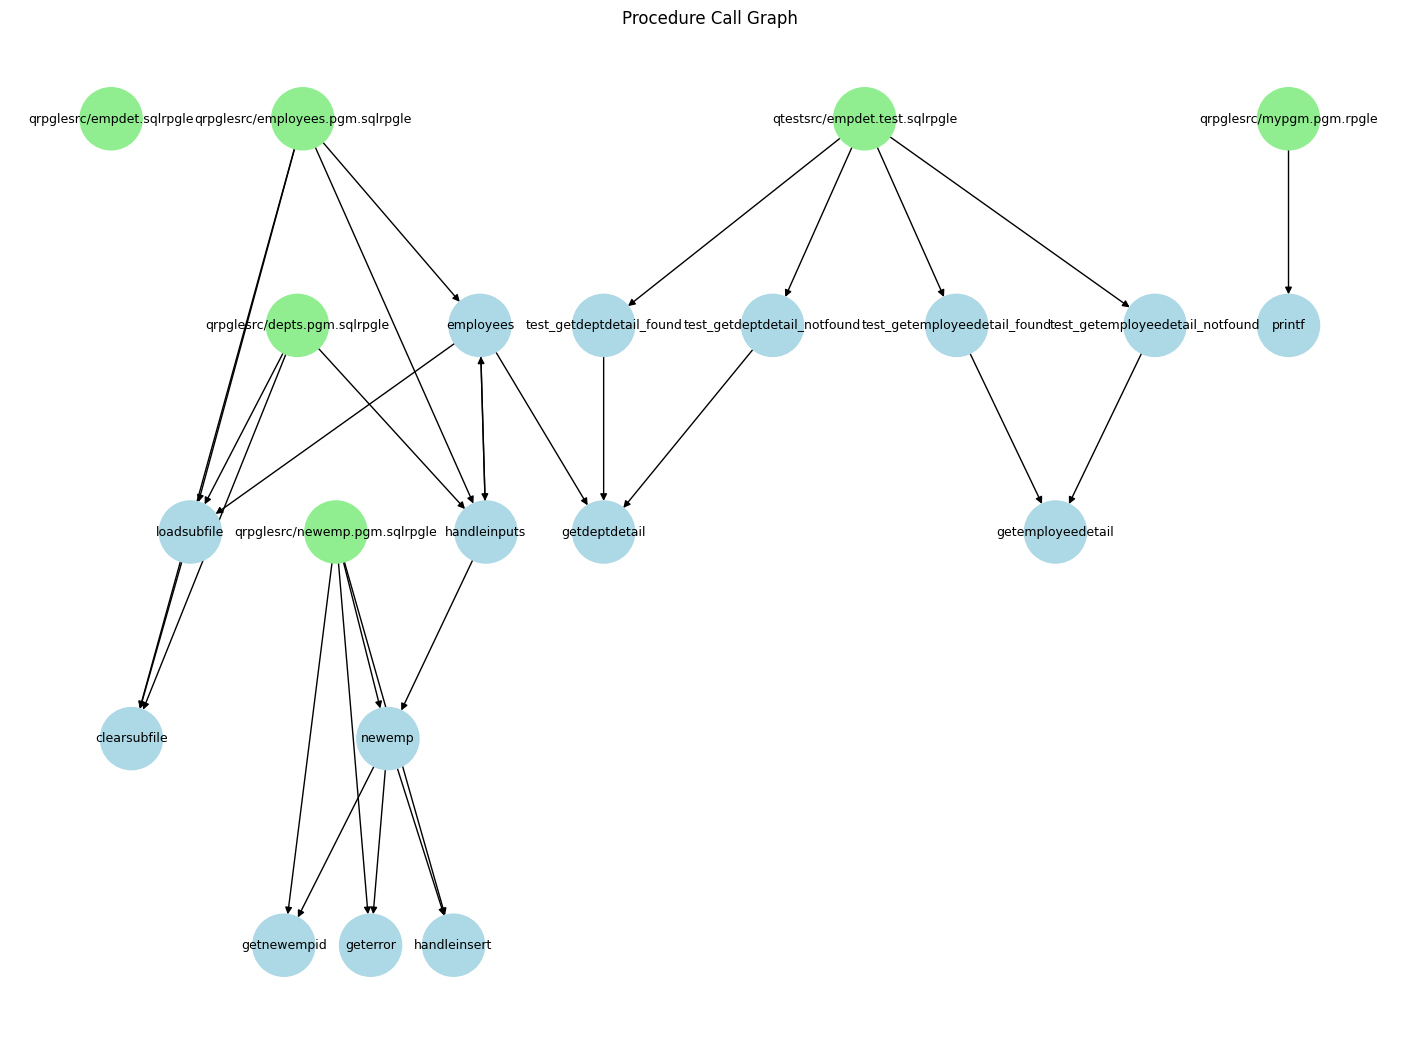

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re
import ast

start = response.content.find('{')
end = response.content.rfind('}') + 1
cleaned_str = response.content[start:end]


call_graph_dict = ast.literal_eval(cleaned_str)

def normalise_proc_name(name):
    return re.sub(r'\s*\(.*\)$', '', name).lower()

G = nx.DiGraph()

def add_nodes_edges(graph_data, parent=None):
    for node, children in graph_data.items():
        if node.startswith('/'):
            parts = node.strip('/').split('/')
            last_two = '/'.join(parts[-2:])
            file_node = last_two
            G.add_node(file_node, type='file')
            if parent:
                G.add_edge(parent, file_node)
            add_nodes_edges(children, parent=file_node)
        else:
            proc_norm = normalise_proc_name(node)
            G.add_node(proc_norm, type='procedure', label=proc_norm)
            if parent:
                G.add_edge(parent, proc_norm)
            add_nodes_edges(children, parent=proc_norm)

add_nodes_edges(call_graph_dict)


try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except ImportError:
    pos = nx.spring_layout(G, k=0.5)

plt.figure(figsize=(14, 10))
node_colors = ['lightgreen' if G.nodes[n].get('type') == 'file' else 'lightblue' for n in G.nodes]

# Draw nodes with labels based on original name (lowercase proc names)
nx.draw(G, pos, labels={n: n for n in G.nodes}, with_labels=True, arrows=True,
        node_size=2000, node_color=node_colors, font_size=9)
plt.title("Procedure Call Graph")
plt.tight_layout()
plt.show()


##Testing on large batches

In [ ]:
import ast

BATCH_SIZE = 20
batches = [split_repo[i:i+BATCH_SIZE] for i in range(0, len(split_repo), BATCH_SIZE)]

all_results = []
for batch in batches:
    human_message = HumanMessage(content=f"""
        Here are the input chunks (content and metadata): {batch}.
        Identify call relationships by matching procedure names and external declarations across files.
    """)
    response = model.invoke([system_message, human_message])
    start = response.content.find('{')
    end = response.content.rfind('}') + 1
    cleaned_str = response.content[start:end]
    call_graph_dict = ast.literal_eval(cleaned_str)
    all_results.append(call_graph_dict)



In [ ]:
def merge_call_graphs(graphs):
    from collections import defaultdict
    import copy

    def merge_dicts(d1, d2):
        for key, val in d2.items():
            if key in d1:
                merge_dicts(d1[key], val)
            else:
                d1[key] = val

    merged = {}
    for graph in graphs:
        merge_dicts(merged, graph)
    return merged

def flatten_top_level(graph):
    """Ensure that each file path maps to a single merged dict."""
    flat_graph = {}
    for file_path, procs in graph.items():
        if isinstance(procs, list):
            combined = {}
            for item in procs:
                if isinstance(item, dict):
                    for k, v in item.items():
                        combined[k] = v
            flat_graph[file_path] = combined
        else:
            flat_graph[file_path] = procs
    return flat_graph

# Apply this before merging:
flattened_results = [flatten_top_level(g) for g in all_results]
merged = merge_call_graphs(flattened_results)


# merged = merge_call_graphs(all_results)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import re
import ast

def normalise_proc_name(name):
    return re.sub(r'\s*\(.*\)$', '', name).lower()

G = nx.DiGraph()

def add_nodes_edges(graph_data, parent=None):
    for node, children in graph_data.items():
        if node.startswith('/'):
            file_node = node
            G.add_node(file_node, type='file')
            if parent:
                G.add_edge(parent, file_node)
            add_nodes_edges(children, parent=file_node)
        else:
            proc_norm = normalise_proc_name(node)
            G.add_node(proc_norm, type='procedure', label=proc_norm)
            if parent:
                G.add_edge(parent, proc_norm)
            add_nodes_edges(children, parent=proc_norm)

add_nodes_edges(merged)


try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except ImportError:
    pos = nx.spring_layout(G, k=0.5)

plt.figure(figsize=(14, 10))
node_colors = ['lightgreen' if G.nodes[n].get('type') == 'file' else 'lightblue' for n in G.nodes]

# Draw nodes with labels based on original name (lowercase proc names)
nx.draw(G, pos, labels={n: n for n in G.nodes}, with_labels=True, arrows=True,
        node_size=2000, node_color=node_colors, font_size=9)
plt.title("Procedure Call Graph")
plt.tight_layout()
plt.show()


"dot" with args ['-Tdot', '/tmp/tmprbd5w3d9/tmpg5vof652'] returned code: 1

stdout, stderr:
 b''
b"Error: /tmp/tmprbd5w3d9/tmpg5vof652: syntax error in line 3 near '['\n"



AssertionError: "dot" with args ['-Tdot', '/tmp/tmprbd5w3d9/tmpg5vof652'] returned code: 1